# 🔵 K-Nearest Neighbors (KNN)

> **Folder:** `03_Supervised_Learning / Classification / K_Nearest_Neighbors`  
> **Notebook:** `knn.ipynb`  
> **Author:** Hamna Munir

---

## 🎯 Objectives

By the end of this notebook, you will:

- Understand how KNN makes predictions using **distance-based voting**
- Visualize the **decision boundary** for different K values
- Find the **optimal K** using validation curves and cross-validation
- Compare **distance metrics** (Euclidean, Manhattan, Chebyshev)
- Compare **uniform vs distance-weighted** KNN
- Handle the **curse of dimensionality** using PCA preprocessing
- Apply KNN for **regression** as well as classification
- Use **GridSearchCV** for full hyperparameter tuning

---

## 📚 Sections

| # | Section | Key Concept |
|---|---------|-------------|
| 1 | Dataset & EDA | Understanding the data |
| 2 | KNN — How It Works | Visual intuition |
| 3 | Decision Boundary Visualization | Effect of K |
| 4 | K Sensitivity — Train vs Test | Bias-variance tradeoff |
| 5 | Validation Curve — Optimal K | CV-based K selection |
| 6 | Distance Metric Comparison | Euclidean vs Manhattan |
| 7 | Uniform vs Distance Weights | Weighted voting |
| 8 | Feature Scaling Impact | Why scaling is critical |
| 9 | GridSearchCV — Full Tuning | Best K + metric + weights |
| 10 | Confusion Matrix + Metrics | Full evaluation |
| 11 | Curse of Dimensionality | PCA + KNN |
| 12 | KNN Regressor | Regression task |
| 13 | Stratified K-Fold CV | Reliable evaluation |

---
## ⚙️ 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV, validation_curve
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay,
    mean_squared_error, r2_score, mean_absolute_error
)
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_classification, make_regression, make_moons

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

COLORS = {
    'primary'  : '#2E86AB',
    'secondary': '#E84855',
    'accent'   : '#3BB273',
    'warning'  : '#F18F01',
    'purple'   : '#7B2D8B',
    'palette'  : ['#2E86AB','#E84855','#3BB273','#F18F01','#7B2D8B','#F4D35E'],
}

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


---
## 📊 1. Dataset & EDA

Shape  : (800, 8)
Classes: {0: 558, 1: 242}
Train  : (640, 8) | Test: (160, 8)


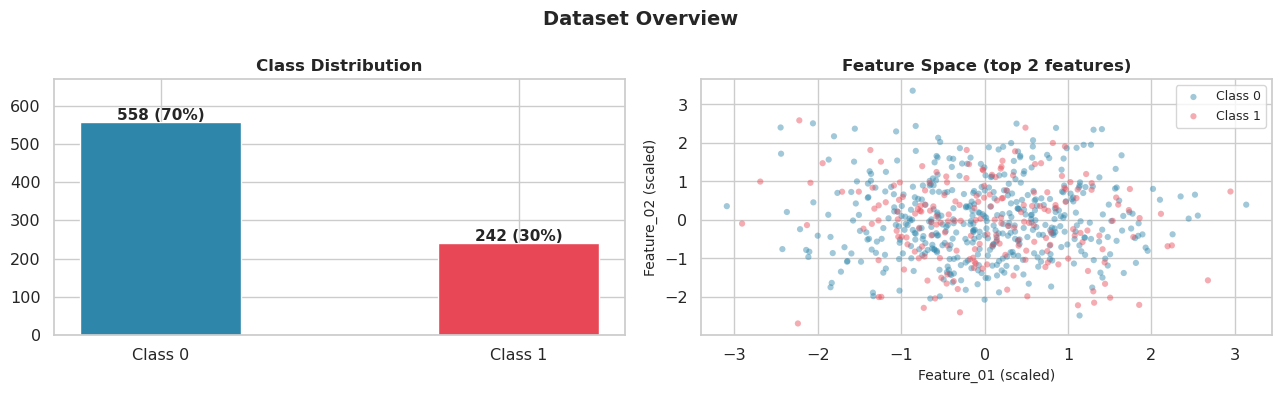

In [2]:
np.random.seed(42)

X_raw, y_raw = make_classification(
    n_samples=800, n_features=8, n_informative=5,
    n_redundant=1, n_classes=2,
    weights=[0.70, 0.30], random_state=42
)

feat_names = [f'Feature_{i+1:02d}' for i in range(8)]
X = pd.DataFrame(X_raw, columns=feat_names)
y = pd.Series(y_raw, name='Target')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler   = StandardScaler()
X_tr_sc  = pd.DataFrame(scaler.fit_transform(X_train), columns=feat_names)
X_te_sc  = pd.DataFrame(scaler.transform(X_test),  columns=feat_names)

print(f'Shape  : {X.shape}')
print(f'Classes: {dict(y.value_counts().sort_index())}')
print(f'Train  : {X_train.shape} | Test: {X_test.shape}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = y.value_counts().sort_index()
bars = axes[0].bar(['Class 0','Class 1'], counts.values,
                    color=[COLORS['primary'], COLORS['secondary']],
                    edgecolor='white', width=0.45)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+5,
                 f'{v} ({v/len(y)*100:.0f}%)', ha='center',
                 fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(counts)*1.2)

for cls, color in [(0, COLORS['primary']), (1, COLORS['secondary'])]:
    axes[1].scatter(
        X_tr_sc.iloc[y_train.values==cls, 0],
        X_tr_sc.iloc[y_train.values==cls, 1],
        c=color, alpha=0.45, s=20, edgecolors='none',
        label=f'Class {cls}'
    )
axes[1].set_xlabel('Feature_01 (scaled)', fontsize=10)
axes[1].set_ylabel('Feature_02 (scaled)', fontsize=10)
axes[1].set_title('Feature Space (top 2 features)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Dataset Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2️⃣ KNN — How It Works (Visual Intuition)

> For a new point ★, KNN finds the K closest training points and takes a **majority vote**.

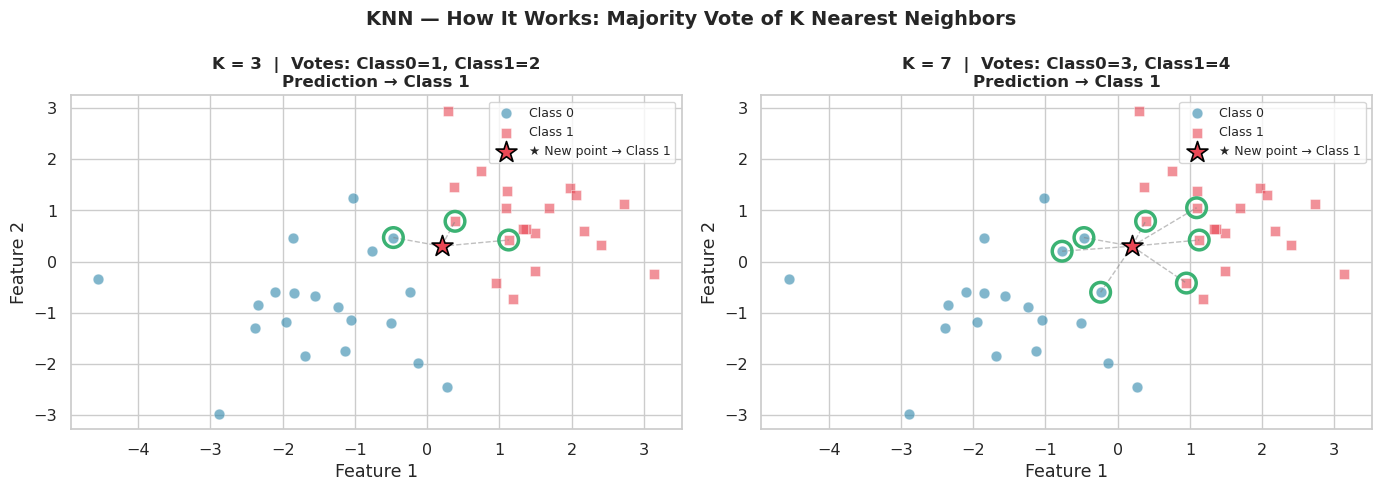

In [3]:
# Small 2D dataset for visualization
np.random.seed(0)
X_vis = np.vstack([
    np.random.randn(20, 2) + [-2, -1],
    np.random.randn(20, 2) + [2, 1]
])
y_vis  = np.array([0]*20 + [1]*20)
x_new  = np.array([[0.2, 0.3]])
dists  = np.sqrt(((X_vis - x_new)**2).sum(axis=1))
sorted_idx = np.argsort(dists)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, K in [(axes[0], 3), (axes[1], 7)]:
    neighbors_idx = sorted_idx[:K]
    votes = y_vis[neighbors_idx]
    predicted = int(np.bincount(votes).argmax())

    for cls, color, marker in [(0, COLORS['primary'], 'o'),
                                (1, COLORS['secondary'], 's')]:
        mask = y_vis == cls
        ax.scatter(X_vis[mask, 0], X_vis[mask, 1],
                   c=color, marker=marker, s=60, alpha=0.6,
                   edgecolors='white', linewidths=0.5, label=f'Class {cls}')

    # Highlight K neighbors with circles
    for idx in neighbors_idx:
        ax.scatter(X_vis[idx, 0], X_vis[idx, 1],
                   s=200, facecolors='none',
                   edgecolors=COLORS['accent'], linewidths=2.5, zorder=4)
        ax.plot([x_new[0,0], X_vis[idx,0]],
                [x_new[0,1], X_vis[idx,1]],
                '--', color='gray', alpha=0.5, lw=1)

    # New point
    pred_color = COLORS['primary'] if predicted==0 else COLORS['secondary']
    ax.scatter(x_new[0,0], x_new[0,1], s=250, marker='*',
               color=pred_color, edgecolors='black', linewidths=1.2,
               zorder=5, label=f'★ New point → Class {predicted}')

    class0 = (votes==0).sum()
    class1 = (votes==1).sum()
    ax.set_title(f'K = {K}  |  Votes: Class0={class0}, Class1={class1}\n'
                 f'Prediction → Class {predicted}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
    ax.legend(fontsize=9)

plt.suptitle('KNN — How It Works: Majority Vote of K Nearest Neighbors',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3️⃣ Decision Boundary Visualization — Effect of K

> Small K = jagged, complex boundary (overfitting).  
> Large K = smooth, simple boundary (underfitting).  
> ✅ Sweet spot: K where test accuracy is highest.

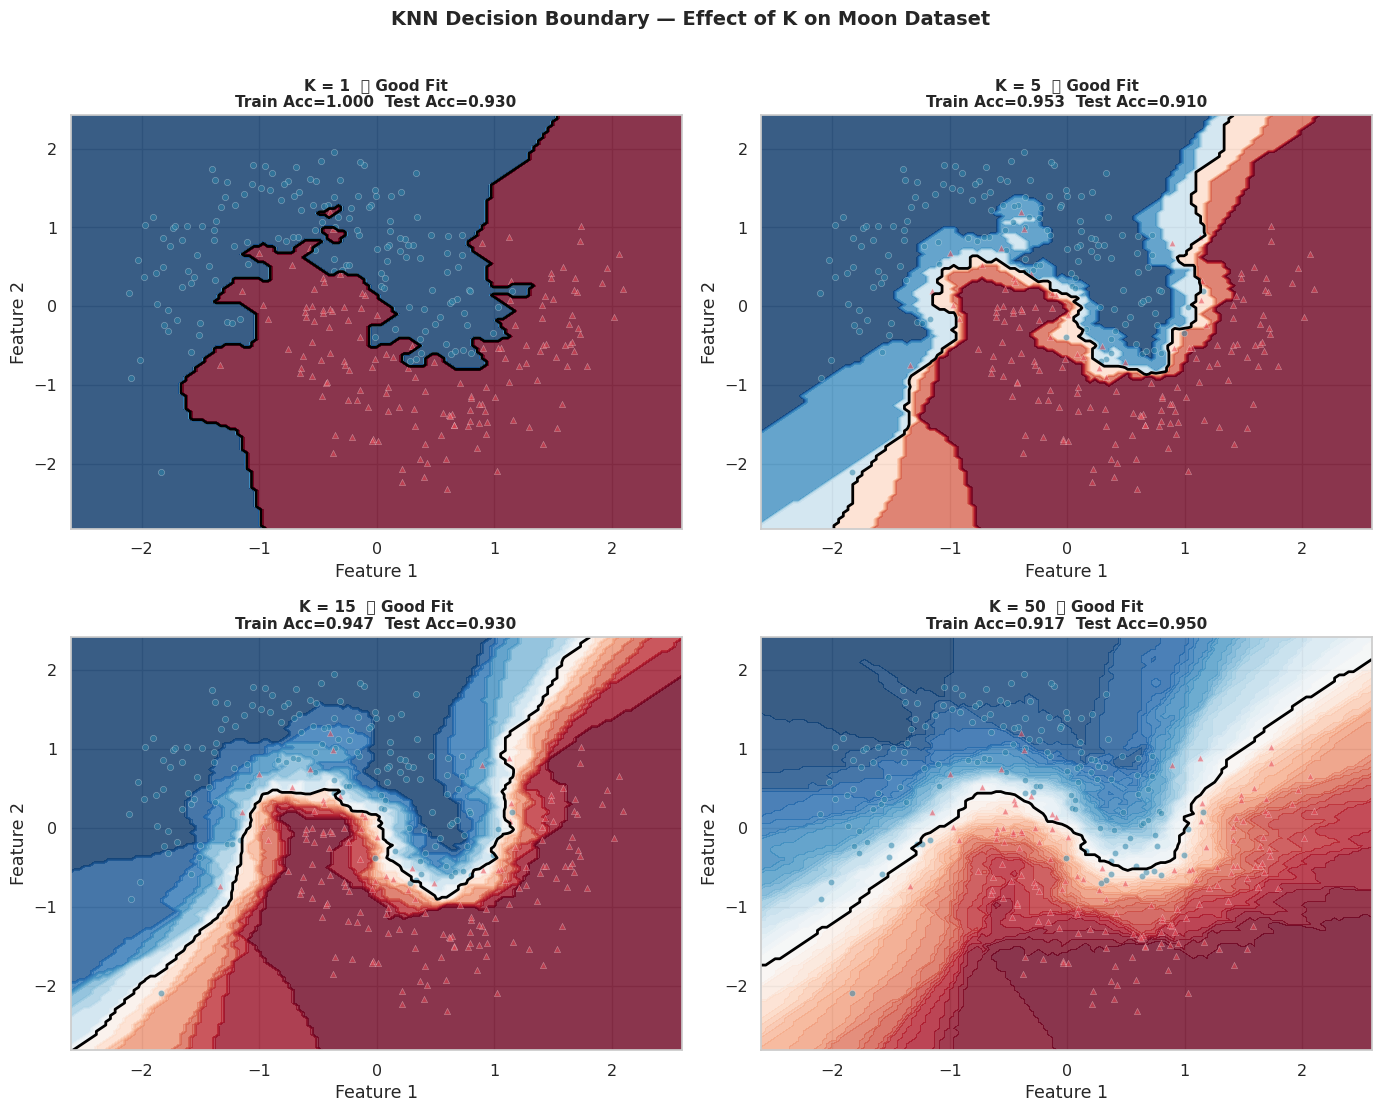

In [4]:
# Use make_moons for a non-linear boundary
X_m, y_m = make_moons(n_samples=400, noise=0.25, random_state=42)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(
    X_m, y_m, test_size=0.25, stratify=y_m, random_state=42
)
sc_m    = StandardScaler()
Xm_tr_sc = sc_m.fit_transform(Xm_tr)
Xm_te_sc = sc_m.transform(Xm_te)

K_values = [1, 5, 15, 50]
h        = 0.04
x1_min, x1_max = Xm_tr_sc[:,0].min()-0.5, Xm_tr_sc[:,0].max()+0.5
x2_min, x2_max = Xm_tr_sc[:,1].min()-0.5, Xm_tr_sc[:,1].max()+0.5
xx, yy  = np.meshgrid(np.arange(x1_min, x1_max, h),
                       np.arange(x2_min, x2_max, h))

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes      = axes.flatten()

for ax, K in zip(axes, K_values):
    knn = KNeighborsClassifier(n_neighbors=K, n_jobs=-1)
    knn.fit(Xm_tr_sc, ym_tr)
    Z  = knn.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)
    tr_acc = accuracy_score(ym_tr, knn.predict(Xm_tr_sc))
    te_acc = accuracy_score(ym_te, knn.predict(Xm_te_sc))

    cf = ax.contourf(xx, yy, Z, levels=50, cmap='RdBu_r', alpha=0.80)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

    for cls, color, marker in [(0, COLORS['primary'],'o'),(1, COLORS['secondary'],'^')]:
        mask = ym_tr == cls
        ax.scatter(Xm_tr_sc[mask,0], Xm_tr_sc[mask,1],
                   c=color, marker=marker, s=20, alpha=0.55,
                   edgecolors='white', linewidths=0.3)

    status = ('⚠️ Overfit' if te_acc < tr_acc - 0.07
              else '❌ Underfit' if te_acc < 0.82
              else '✅ Good Fit')
    ax.set_title(f'K = {K}  {status}\n'
                 f'Train Acc={tr_acc:.3f}  Test Acc={te_acc:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')

plt.suptitle('KNN Decision Boundary — Effect of K on Moon Dataset',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 4️⃣ K Sensitivity — Train vs Test Accuracy

> **K=1:** Perfect train accuracy, poor generalization (overfitting).  
> **Large K:** Train and test scores converge but both may drop (underfitting).

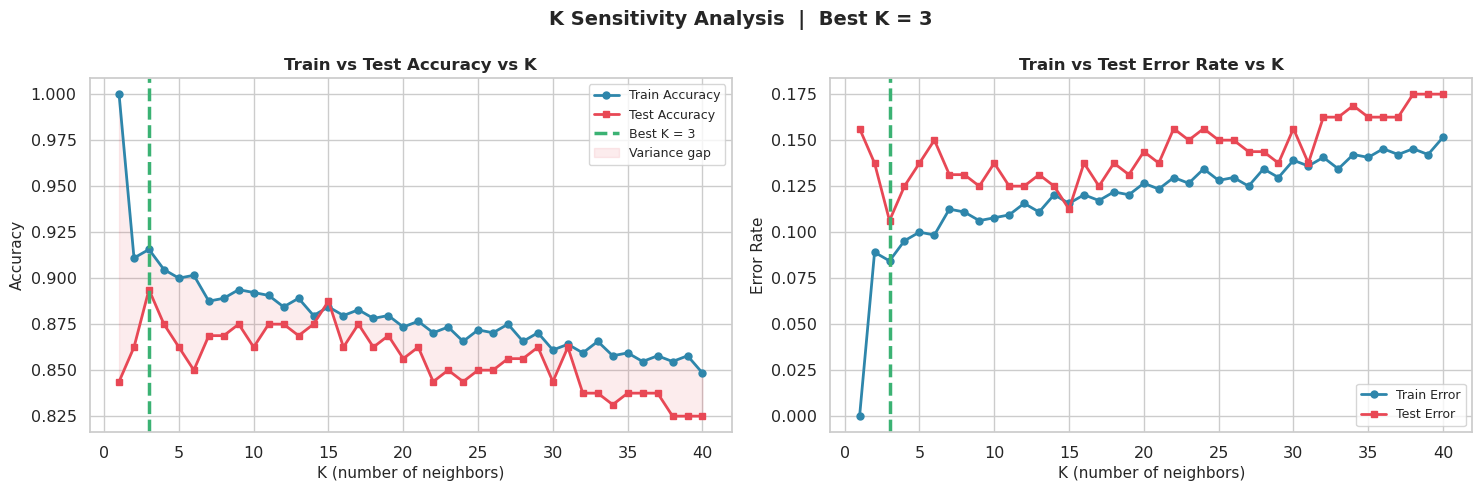

Best K: 3  |  Test Accuracy: 0.8938


In [5]:
k_range    = list(range(1, 41))
tr_accs, te_accs = [], []

for K in k_range:
    knn = KNeighborsClassifier(n_neighbors=K, n_jobs=-1)
    knn.fit(X_tr_sc, y_train)
    tr_accs.append(accuracy_score(y_train, knn.predict(X_tr_sc)))
    te_accs.append(accuracy_score(y_test,  knn.predict(X_te_sc)))

best_k = k_range[np.argmax(te_accs)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(k_range, tr_accs, 'o-', color=COLORS['primary'],
              lw=2, ms=5, label='Train Accuracy')
axes[0].plot(k_range, te_accs, 's-', color=COLORS['secondary'],
              lw=2, ms=5, label='Test Accuracy')
axes[0].axvline(best_k, color=COLORS['accent'], lw=2.5,
                 linestyle='--', label=f'Best K = {best_k}')
axes[0].fill_between(k_range, tr_accs, te_accs,
                      alpha=0.10, color=COLORS['secondary'], label='Variance gap')
axes[0].set_xlabel('K (number of neighbors)', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Train vs Test Accuracy vs K', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xticks(range(0, 41, 5))

# Error rate
tr_err = [1-a for a in tr_accs]
te_err = [1-a for a in te_accs]
axes[1].plot(k_range, tr_err, 'o-', color=COLORS['primary'],
              lw=2, ms=5, label='Train Error')
axes[1].plot(k_range, te_err, 's-', color=COLORS['secondary'],
              lw=2, ms=5, label='Test Error')
axes[1].axvline(best_k, color=COLORS['accent'], lw=2.5, linestyle='--')
axes[1].set_xlabel('K (number of neighbors)', fontsize=11)
axes[1].set_ylabel('Error Rate', fontsize=11)
axes[1].set_title('Train vs Test Error Rate vs K', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xticks(range(0, 41, 5))

plt.suptitle(f'K Sensitivity Analysis  |  Best K = {best_k}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Best K: {best_k}  |  Test Accuracy: {max(te_accs):.4f}')

---
## 5️⃣ Validation Curve — Optimal K via Cross-Validation

> Cross-validation gives a more reliable estimate than a single train/test split.  
> ✅ Always use CV to select K — never use test set for this.

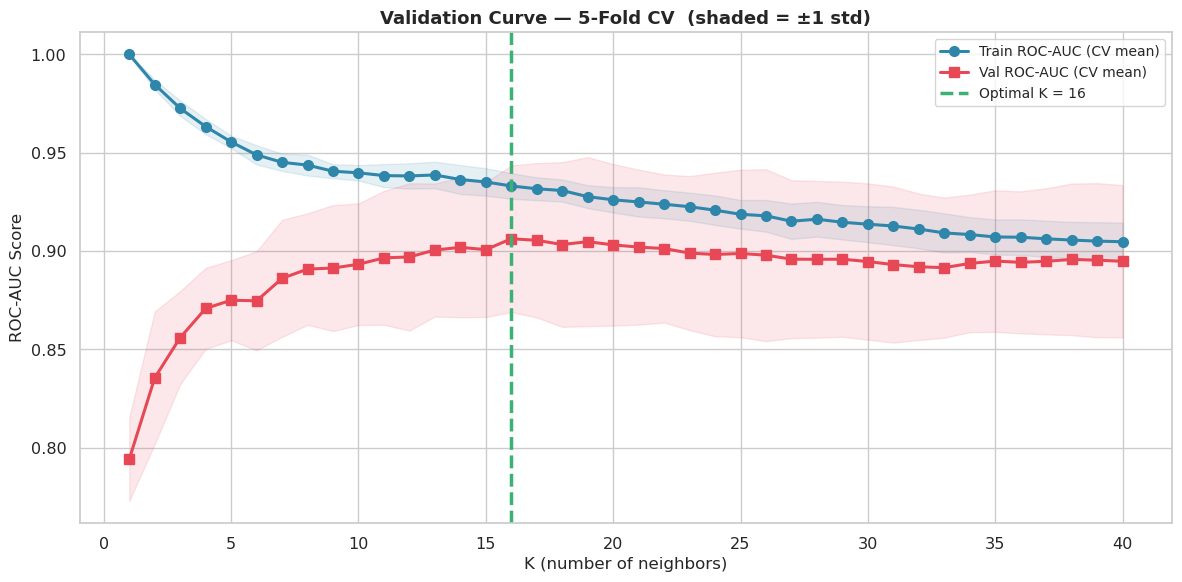

Optimal K (CV): 16
Val AUC: 0.9063 ± 0.0373


In [6]:
pipe_vc   = Pipeline([('sc', StandardScaler()),
                       ('knn', KNeighborsClassifier(n_jobs=-1))])
k_range_vc = range(1, 41)

train_sc, val_sc = validation_curve(
    pipe_vc, X_train, y_train,
    param_name='knn__n_neighbors',
    param_range=k_range_vc,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)

t_mean, t_std = train_sc.mean(1), train_sc.std(1)
v_mean, v_std = val_sc.mean(1),   val_sc.std(1)
best_cv_k     = list(k_range_vc)[np.argmax(v_mean)]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(k_range_vc, t_mean, 'o-', color=COLORS['primary'],
         lw=2.2, ms=7, label='Train ROC-AUC (CV mean)')
ax.fill_between(k_range_vc, t_mean-t_std, t_mean+t_std,
                 alpha=0.12, color=COLORS['primary'])
ax.plot(k_range_vc, v_mean, 's-', color=COLORS['secondary'],
         lw=2.2, ms=7, label='Val ROC-AUC (CV mean)')
ax.fill_between(k_range_vc, v_mean-v_std, v_mean+v_std,
                 alpha=0.12, color=COLORS['secondary'])
ax.axvline(best_cv_k, color=COLORS['accent'], lw=2.5,
            linestyle='--', label=f'Optimal K = {best_cv_k}')
ax.set_xlabel('K (number of neighbors)', fontsize=12)
ax.set_ylabel('ROC-AUC Score', fontsize=12)
ax.set_title('Validation Curve — 5-Fold CV  (shaded = ±1 std)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xticks(range(0, 41, 5))
plt.tight_layout()
plt.show()

print(f'Optimal K (CV): {best_cv_k}')
print(f'Val AUC: {v_mean[best_cv_k-1]:.4f} ± {v_std[best_cv_k-1]:.4f}')

---
## 6️⃣ Distance Metric Comparison

> Different distance metrics define "closeness" differently.  
> The best metric depends on the geometry of your feature space.

Distance Metric Comparison (K=16):
   Metric  Accuracy     F1  ROC-AUC  Precision  Recall
euclidean    0.8625 0.7250   0.8906     0.9062  0.6042
manhattan    0.8625 0.7250   0.9033     0.9062  0.6042
chebyshev    0.8313 0.6494   0.8653     0.8621  0.5208
minkowski    0.8625 0.7250   0.8831     0.9062  0.6042


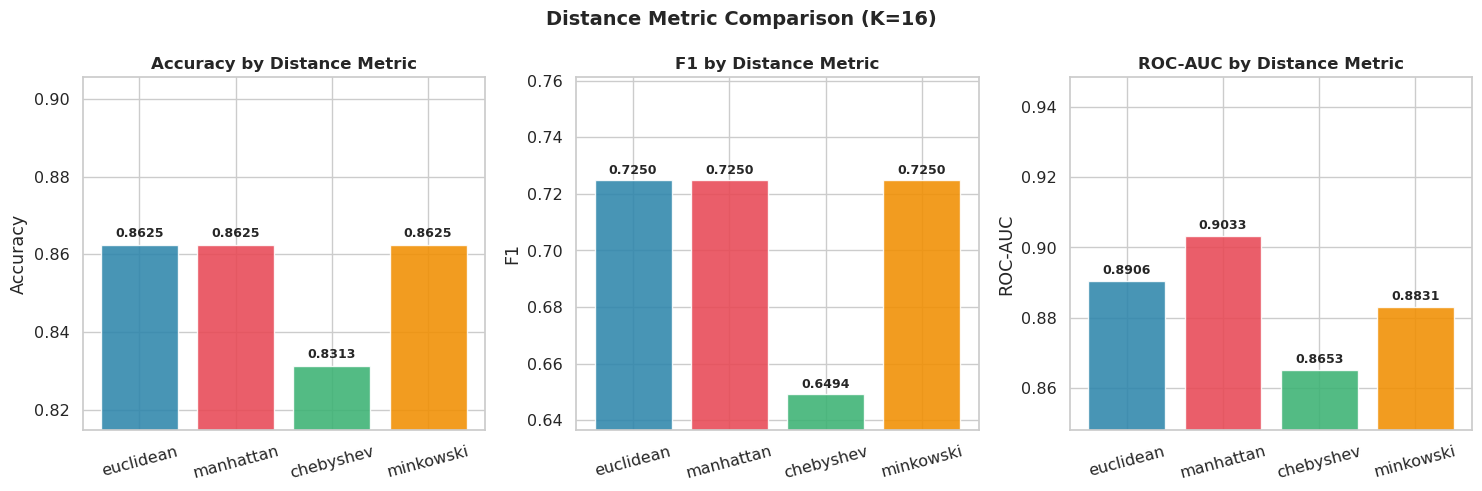

In [7]:
metrics_list = [
    ('euclidean',  {}),
    ('manhattan',  {}),
    ('chebyshev',  {}),
    ('minkowski',  {'p': 3}),
]

metric_rows = []
for metric_name, metric_params in metrics_list:
    knn = KNeighborsClassifier(
        n_neighbors=best_cv_k,
        metric=metric_name,
        metric_params=metric_params if metric_params else None,
        n_jobs=-1
    )
    knn.fit(X_tr_sc, y_train)
    y_pred_m = knn.predict(X_te_sc)
    y_prob_m = knn.predict_proba(X_te_sc)[:, 1]
    metric_rows.append({
        'Metric'   : metric_name,
        'Accuracy' : round(accuracy_score(y_test, y_pred_m), 4),
        'F1'       : round(f1_score(y_test, y_pred_m), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob_m), 4),
        'Precision': round(precision_score(y_test, y_pred_m), 4),
        'Recall'   : round(recall_score(y_test, y_pred_m), 4),
    })

metric_df = pd.DataFrame(metric_rows)
print(f'Distance Metric Comparison (K={best_cv_k}):')
print(metric_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
eval_cols  = ['Accuracy', 'F1', 'ROC-AUC']

for ax, col in zip(axes, eval_cols):
    bars = ax.bar(metric_df['Metric'], metric_df[col],
                   color=COLORS['palette'][:4], edgecolor='white', alpha=0.88)
    ax.set_ylabel(col)
    ax.set_title(f'{col} by Distance Metric', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, metric_df[col]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
    mn = metric_df[col].min()
    ax.set_ylim(mn*0.98, metric_df[col].max()*1.05)

plt.suptitle(f'Distance Metric Comparison (K={best_cv_k})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7️⃣ Uniform vs Distance-Weighted KNN

> **Uniform:** All K neighbors vote equally.  
> **Distance:** Closer neighbors vote more strongly (weight = 1/distance²).  
> ✅ Distance weighting often helps when the K-th neighbor is much farther.

Uniform vs Distance Weights — Accuracy per K:
Weights  distance  uniform
K                         
1          0.8438   0.8438
3          0.8938   0.8938
5          0.8625   0.8625
7          0.8688   0.8688
10         0.8750   0.8625
15         0.8812   0.8875
20         0.8688   0.8562
25         0.8625   0.8500
30         0.8625   0.8438


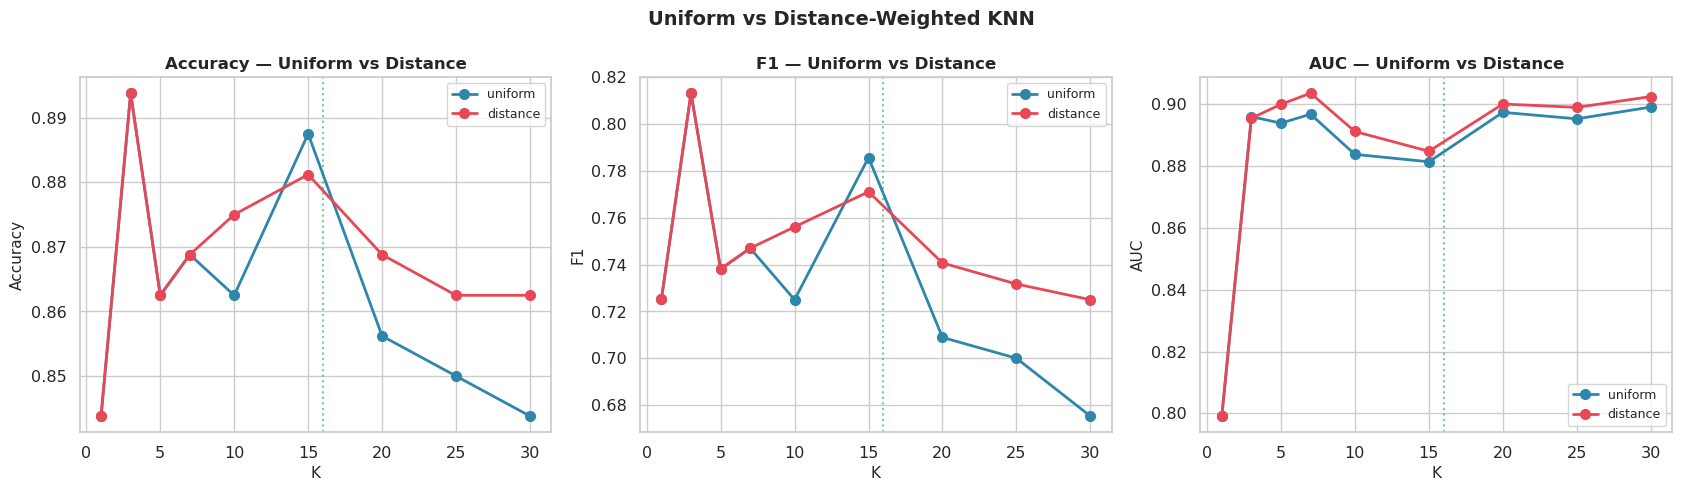

In [8]:
k_vals   = [1, 3, 5, 7, 10, 15, 20, 25, 30]
w_rows   = []

for K in k_vals:
    for w in ['uniform', 'distance']:
        knn = KNeighborsClassifier(n_neighbors=K, weights=w, n_jobs=-1)
        knn.fit(X_tr_sc, y_train)
        yp = knn.predict(X_te_sc)
        ypr = knn.predict_proba(X_te_sc)[:, 1]
        w_rows.append({
            'K': K, 'Weights': w,
            'Accuracy': round(accuracy_score(y_test, yp), 4),
            'F1'      : round(f1_score(y_test, yp), 4),
            'AUC'     : round(roc_auc_score(y_test, ypr), 4),
        })

w_df   = pd.DataFrame(w_rows)
pivot  = w_df.pivot(index='K', columns='Weights', values='Accuracy')
print('Uniform vs Distance Weights — Accuracy per K:')
print(pivot.to_string())

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, metric in zip(axes, ['Accuracy', 'F1', 'AUC']):
    for w, color in [('uniform', COLORS['primary']),
                     ('distance', COLORS['secondary'])]:
        sub = w_df[w_df['Weights'] == w]
        ax.plot(sub['K'], sub[metric], 'o-', color=color,
                 lw=2, ms=7, label=f'{w}')
    ax.axvline(best_cv_k, color=COLORS['accent'], lw=1.5,
                linestyle=':', alpha=0.7)
    ax.set_xlabel('K', fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f'{metric} — Uniform vs Distance',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Uniform vs Distance-Weighted KNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8️⃣ Feature Scaling Impact — Why Scaling is Critical

> Without scaling, features with large ranges dominate the distance calculation.  
> ✅ KNN is one of the algorithms that **requires** feature scaling.

Feature Scaling Impact on KNN Accuracy:
 K  Not Scaled  StandardScaled  Improvement
 3      0.6687          0.8938       0.2250
 5      0.6250          0.8625       0.2375
 7      0.6312          0.8688       0.2375
10      0.6813          0.8625       0.1813
15      0.7000          0.8875       0.1875


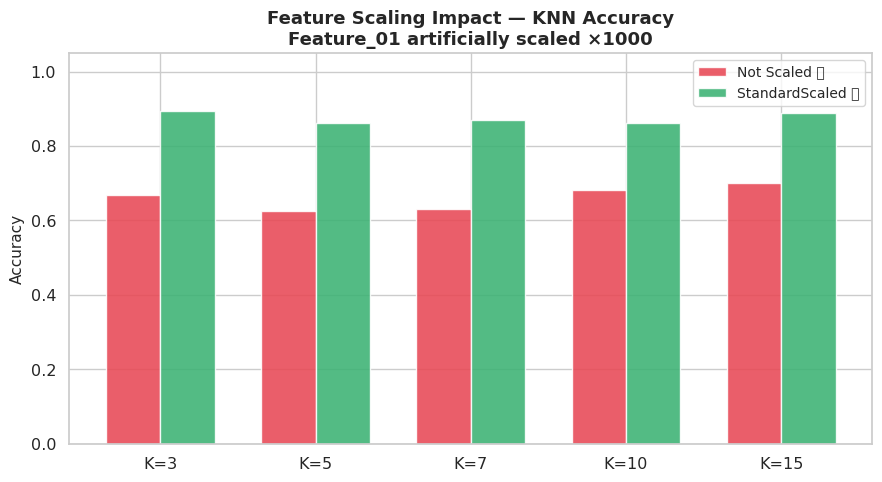

In [9]:
# Create unscaled version with deliberately different scales
X_unscaled = X_train.copy()
X_unscaled['Feature_01'] = X_unscaled['Feature_01'] * 1000   # large range
X_unscaled_test = X_test.copy()
X_unscaled_test['Feature_01'] = X_unscaled_test['Feature_01'] * 1000

# Standard scaled version
sc2 = StandardScaler()
X_sc2 = sc2.fit_transform(X_unscaled)
X_sc2_te = sc2.transform(X_unscaled_test)

scale_rows = []
for K in [3, 5, 7, 10, 15]:
    knn = KNeighborsClassifier(n_neighbors=K, n_jobs=-1)

    knn.fit(X_unscaled.values, y_train)
    acc_unscaled = accuracy_score(y_test, knn.predict(X_unscaled_test.values))

    knn.fit(X_sc2, y_train)
    acc_scaled = accuracy_score(y_test, knn.predict(X_sc2_te))

    scale_rows.append({
        'K'            : K,
        'Not Scaled'   : round(acc_unscaled, 4),
        'StandardScaled': round(acc_scaled, 4),
        'Improvement'  : round(acc_scaled - acc_unscaled, 4),
    })

scale_df = pd.DataFrame(scale_rows)
print('Feature Scaling Impact on KNN Accuracy:')
print(scale_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(scale_df)); w = 0.35
ax.bar(x-w/2, scale_df['Not Scaled'],    w, color=COLORS['secondary'],
        edgecolor='white', label='Not Scaled ❌', alpha=0.88)
ax.bar(x+w/2, scale_df['StandardScaled'], w, color=COLORS['accent'],
        edgecolor='white', label='StandardScaled ✅', alpha=0.88)
ax.set_xticks(x)
ax.set_xticklabels([f'K={k}' for k in scale_df['K']])
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Feature Scaling Impact — KNN Accuracy\n'
              'Feature_01 artificially scaled ×1000',
              fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

---
## 9️⃣ GridSearchCV — Full KNN Tuning

Best params : {'knn__metric': 'manhattan', 'knn__n_neighbors': 15, 'knn__weights': 'distance'}
Best CV AUC : 0.9096
Test AUC    : 0.9014
Test F1     : 0.7619
Test Acc    : 0.8750


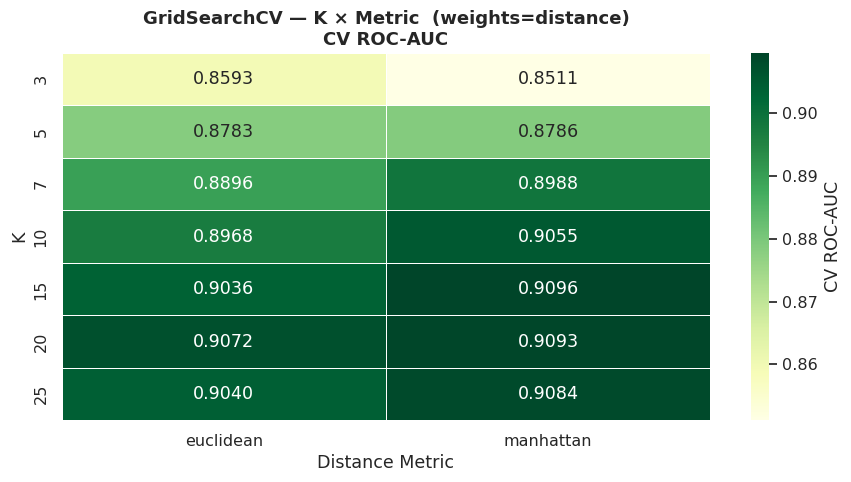

In [10]:
pipe_gs    = Pipeline([('sc', StandardScaler()),
                        ('knn', KNeighborsClassifier(n_jobs=-1))])
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 10, 15, 20, 25],
    'knn__weights'    : ['uniform', 'distance'],
    'knn__metric'     : ['euclidean', 'manhattan'],
}

gs = GridSearchCV(
    pipe_gs, param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)
gs.fit(X_train, y_train)

print(f'Best params : {gs.best_params_}')
print(f'Best CV AUC : {gs.best_score_:.4f}')

y_gs_pred = gs.predict(X_test)
y_gs_prob = gs.predict_proba(X_test)[:, 1]
print(f'Test AUC    : {roc_auc_score(y_test, y_gs_prob):.4f}')
print(f'Test F1     : {f1_score(y_test, y_gs_pred):.4f}')
print(f'Test Acc    : {accuracy_score(y_test, y_gs_pred):.4f}')

# Heatmap: K vs metric (best weights)
cv_res = pd.DataFrame(gs.cv_results_)
best_w  = gs.best_params_['knn__weights']
subset  = cv_res[cv_res['param_knn__weights']==best_w]
pivot   = subset.pivot_table(
    index='param_knn__n_neighbors',
    columns='param_knn__metric',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn',
             linewidths=0.5, ax=ax,
             cbar_kws={'label': 'CV ROC-AUC'})
ax.set_title(f'GridSearchCV — K × Metric  (weights={best_w})\nCV ROC-AUC',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Distance Metric'); ax.set_ylabel('K')
plt.tight_layout()
plt.show()

---
## 🔟 Confusion Matrix + Full Metrics

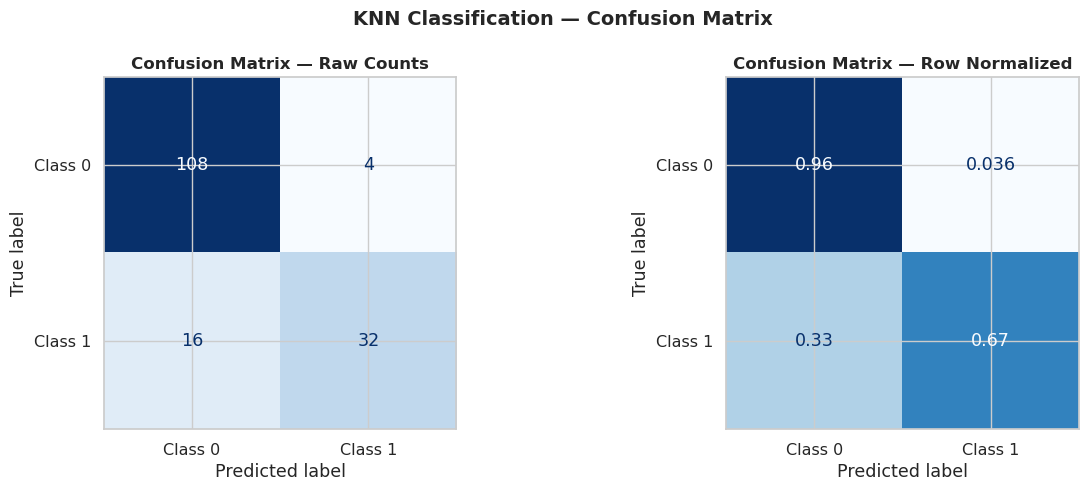

              precision    recall  f1-score   support

     Class 0       0.87      0.96      0.92       112
     Class 1       0.89      0.67      0.76        48

    accuracy                           0.88       160
   macro avg       0.88      0.82      0.84       160
weighted avg       0.88      0.88      0.87       160



In [11]:
# Best model from GridSearchCV
cm = confusion_matrix(y_test, y_gs_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(cm, display_labels=['Class 0','Class 1']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=12, fontweight='bold')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm.round(3), display_labels=['Class 0','Class 1']).plot(
    ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix — Row Normalized', fontsize=12, fontweight='bold')

plt.suptitle('KNN Classification — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_gs_pred, target_names=['Class 0','Class 1']))

---
## 1️⃣1️⃣ Curse of Dimensionality — PCA + KNN

> KNN degrades in high dimensions — all points become equidistant.  
> ✅ Apply PCA to reduce dimensions before KNN on high-dimensional data.

  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Curse of Dimensionality — KNN Accuracy vs Feature Dimensions:
 Dimensions  Accuracy       Method
         50    0.7083 Raw (no PCA)
         30    0.6917      PCA(30)
         20    0.7417      PCA(20)
         10    0.7917      PCA(10)
          5    0.7500       PCA(5)
          3    0.7333       PCA(3)
          2    0.6333       PCA(2)


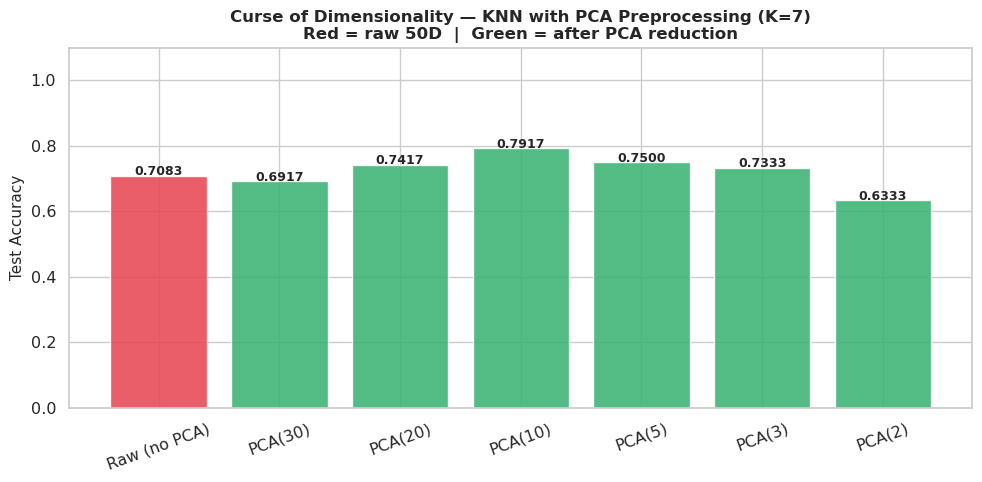

In [12]:
# High-dimensional dataset
X_hd_raw, y_hd = make_classification(
    n_samples=600, n_features=50, n_informative=8,
    n_redundant=5, random_state=42
)
X_hd = pd.DataFrame(X_hd_raw)
Xhd_tr, Xhd_te, yhd_tr, yhd_te = train_test_split(
    X_hd, y_hd, test_size=0.2, stratify=y_hd, random_state=42
)

dim_rows = []
for n_comp in [50, 30, 20, 10, 5, 3, 2]:
    if n_comp == 50:
        # Raw (no PCA)
        pipe_ = Pipeline([('sc', StandardScaler()),
                           ('knn', KNeighborsClassifier(n_neighbors=7, n_jobs=-1))])
    else:
        pipe_ = Pipeline([('sc', StandardScaler()),
                           ('pca', PCA(n_components=n_comp, random_state=42)),
                           ('knn', KNeighborsClassifier(n_neighbors=7, n_jobs=-1))])
    pipe_.fit(Xhd_tr, yhd_tr)
    acc = accuracy_score(yhd_te, pipe_.predict(Xhd_te))
    dim_rows.append({'Dimensions': n_comp, 'Accuracy': round(acc, 4),
                     'Method': 'Raw (no PCA)' if n_comp==50 else f'PCA({n_comp})'})

dim_df = pd.DataFrame(dim_rows)
print('Curse of Dimensionality — KNN Accuracy vs Feature Dimensions:')
print(dim_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors_ = [COLORS['secondary'] if r['Method']=='Raw (no PCA)'
            else COLORS['accent'] for _, r in dim_df.iterrows()]
bars = ax.bar(dim_df['Method'], dim_df['Accuracy'],
               color=colors_, edgecolor='white', alpha=0.88)
for bar, val in zip(bars, dim_df['Accuracy']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Test Accuracy', fontsize=11)
ax.set_title('Curse of Dimensionality — KNN with PCA Preprocessing (K=7)\n'
              'Red = raw 50D  |  Green = after PCA reduction',
              fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=20)
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

---
## 1️⃣2️⃣ KNN Regressor

> The same K-nearest-neighbor logic applies to regression:  
> predict the **mean** (or weighted mean) of the K neighbors' target values.

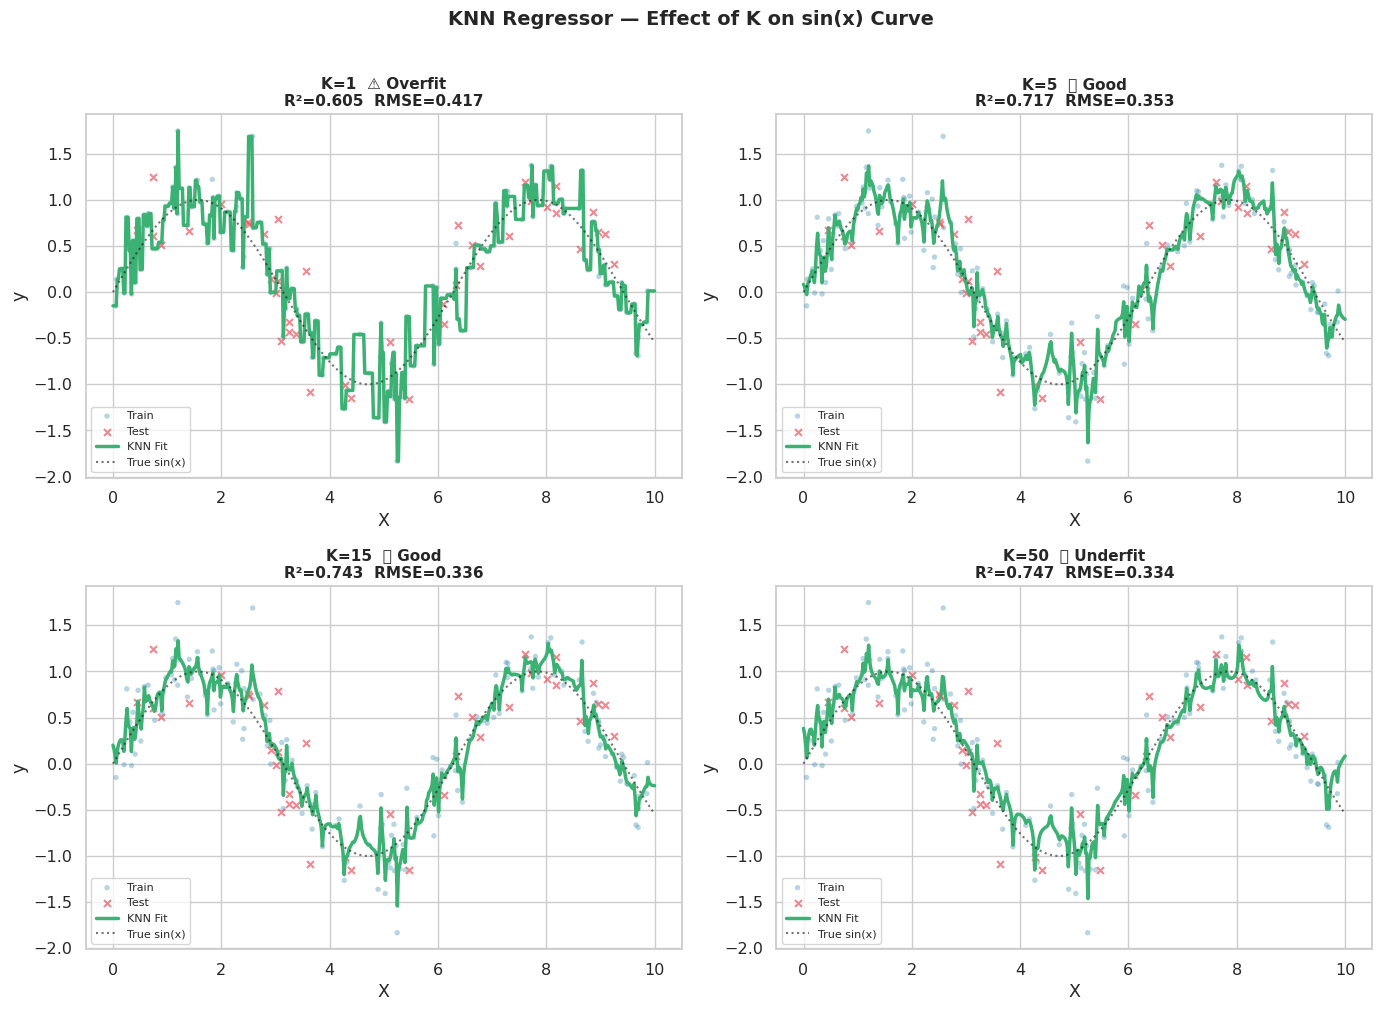

In [13]:
# 1D regression for visualization
np.random.seed(42)
n_reg   = 200
X_1d    = np.sort(np.random.uniform(0, 10, n_reg)).reshape(-1, 1)
y_1d    = np.sin(X_1d).ravel() + np.random.randn(n_reg) * 0.3

X1_tr, X1_te, y1_tr, y1_te = train_test_split(
    X_1d, y_1d, test_size=0.2, random_state=42
)
sc_reg = StandardScaler()
X1_tr_sc = sc_reg.fit_transform(X1_tr)
X1_te_sc = sc_reg.transform(X1_te)

X_plot = np.linspace(0, 10, 500).reshape(-1, 1)
X_plot_sc = sc_reg.transform(X_plot)

K_reg_vals = [1, 5, 15, 50]
fig, axes  = plt.subplots(2, 2, figsize=(14, 10))
axes       = axes.flatten()

for ax, K in zip(axes, K_reg_vals):
    knn_r = KNeighborsRegressor(n_neighbors=K, weights='distance')
    knn_r.fit(X1_tr_sc, y1_tr)
    y_line   = knn_r.predict(X_plot_sc)
    te_r2    = r2_score(y1_te, knn_r.predict(X1_te_sc))
    te_rmse  = np.sqrt(mean_squared_error(y1_te, knn_r.predict(X1_te_sc)))

    ax.scatter(X1_tr, y1_tr, alpha=0.35, s=15,
               color=COLORS['primary'], edgecolors='none', label='Train')
    ax.scatter(X1_te, y1_te, alpha=0.65, s=25, marker='x',
               color=COLORS['secondary'], label='Test')
    ax.plot(X_plot, y_line, color=COLORS['accent'], lw=2.5, label='KNN Fit')
    ax.plot(X_plot, np.sin(X_plot), 'k:', lw=1.5, alpha=0.6, label='True sin(x)')

    status = '⚠️ Overfit' if K==1 else ('❌ Underfit' if K==50 else '✅ Good')
    ax.set_title(f'K={K}  {status}\nR²={te_r2:.3f}  RMSE={te_rmse:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('X'); ax.set_ylabel('y')
    ax.legend(fontsize=8)

plt.suptitle('KNN Regressor — Effect of K on sin(x) Curve',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 1️⃣3️⃣ Stratified K-Fold Cross-Validation — Final Evaluation

Final Model: K=15 | weights=distance | metric=manhattan

Stratified 5-Fold CV Results:
  ROC-AUC   : 0.9089 ± 0.0390  | Folds: [0.929, 0.9347, 0.9422, 0.8355, 0.9033]
  F1        : 0.7710 ± 0.0610  | Folds: [0.7907, 0.8, 0.8222, 0.6512, 0.7907]
  Accuracy  : 0.8762 ± 0.0322  | Folds: [0.8875, 0.8938, 0.9, 0.8125, 0.8875]


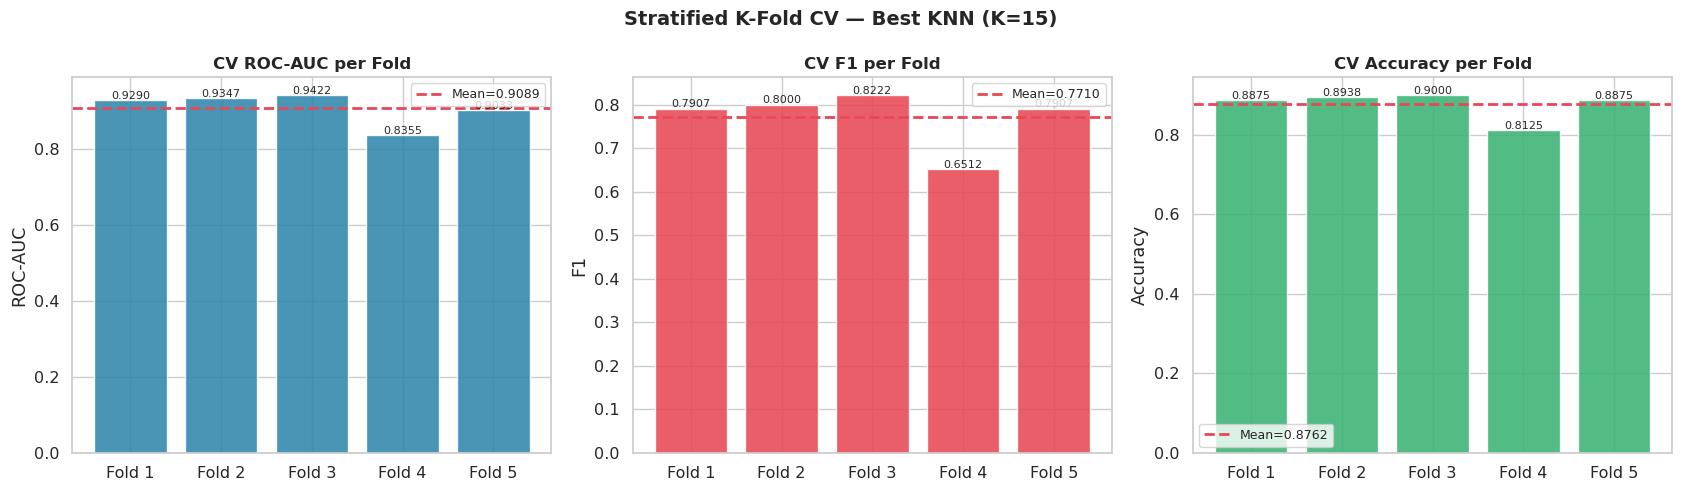

In [14]:
best_k_cv = gs.best_params_['knn__n_neighbors']
best_w_cv = gs.best_params_['knn__weights']
best_m_cv = gs.best_params_['knn__metric']

final_pipe = Pipeline([
    ('sc',  StandardScaler()),
    ('knn', KNeighborsClassifier(
        n_neighbors=best_k_cv, weights=best_w_cv,
        metric=best_m_cv, n_jobs=-1
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_metrics = {
    'ROC-AUC' : cross_val_score(final_pipe, X, y, cv=skf, scoring='roc_auc'),
    'F1'      : cross_val_score(final_pipe, X, y, cv=skf, scoring='f1'),
    'Accuracy': cross_val_score(final_pipe, X, y, cv=skf, scoring='accuracy'),
}

print(f'Final Model: K={best_k_cv} | weights={best_w_cv} | metric={best_m_cv}')
print('\nStratified 5-Fold CV Results:')
for metric, scores in cv_metrics.items():
    print(f'  {metric:10s}: {scores.mean():.4f} ± {scores.std():.4f}  '
          f'| Folds: {[round(s,4) for s in scores]}')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
folds = [f'Fold {i+1}' for i in range(5)]

for ax, (metric, scores), color in zip(
    axes, cv_metrics.items(), COLORS['palette'][:3]
):
    ax.bar(folds, scores, color=color, edgecolor='white', alpha=0.88)
    ax.axhline(scores.mean(), color=COLORS['secondary'], lw=2,
                linestyle='--', label=f'Mean={scores.mean():.4f}')
    ax.set_ylabel(metric)
    ax.set_title(f'CV {metric} per Fold', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    for i, v in enumerate(scores):
        ax.text(i, v+0.003, f'{v:.4f}', ha='center', fontsize=8)

plt.suptitle(f'Stratified K-Fold CV — Best KNN (K={best_k_cv})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ✅ 14. Summary & Best Practices

| Aspect | Key Point |
|--------|----------|
| **Core Idea** | Majority vote of K nearest neighbors by distance |
| **Training** | No training — stores all data (lazy learner) |
| **Prediction** | O(n×d) per point — slow for large datasets |
| **Scaling** | MANDATORY — distance is scale-sensitive |
| **K selection** | Use validation curve or StratifiedKFold CV |
| **Weights** | 'distance' often better than 'uniform' |
| **High dimensions** | Apply PCA first — curse of dimensionality |
| **K=1** | Overfits — avoid in production |

### 🔑 Golden Rules

1. **Always StandardScale** before KNN — distance is meaningless without scaling
2. **Use odd K** for binary classification — avoids ties
3. **Start with K = √n** as a rule of thumb, then tune with CV
4. **Never use K=1 in production** — too sensitive to noise and outliers
5. **Try distance weighting** — often better than uniform, especially for small K
6. **Apply PCA** before KNN on high-dimensional data (> 20 features)
7. **Use StratifiedKFold** for CV — preserves class distribution
8. **GridSearchCV over K, weights, metric** — all three interact

---

## 🔗 Next Steps

- ➡️ `Naive_Bayes/` — Probabilistic classifier, no distance needed
- ➡️ `Decision_Trees/` — Non-linear, no scaling required
- ➡️ `Support_Vector_Machine/` — Also distance-based but finds optimal margin
- ➡️ `04_Unsupervised_Learning/KMeans/` — Distance-based clustering
- ➡️ `06_Feature_Selection/` — Reduce dimensions before KNN